Universidade Federal do Rio Grande do Sul (UFRGS)   
Programa de Pós-Graduação em Engenharia Civil (PPGEC)   

# PEC00025: Introduction to Vibration Theory


## Test P2 (2026/1): Discrete and continuous mdof systems

---

**NAME:** <br/>
**CARD:** 



In [1]:
# Importing Python modules required for this notebook
# (this cell must be executed with "shift+enter" before any other Python cell)

import numpy as np
import matplotlib.pyplot as plt
import pickle as pk
import scipy.linalg as sc

from MRPy import *



In [2]:
def vibration_modes(D, M):

# Uses scipy to solve the eigenvalue problem (with dynamic matrix D)
    l2, Phi = sc.eig(D)
    w2  = 1/l2

# Ensure ascending order of eigenvalues
    iw  = w2.argsort()
    w2  = w2[iw]
    Phi = Phi[:,iw]
    
# Eigenvalues to vibration frequencies
    wk  = np.sqrt(np.real(w2)) 
    fk  = wk/2/np.pi

# Mass matrix normalization (Mk = 1 for all k)
    for k in range(len(wk)):
        Mk       = np.sum(np.diag(M)*Phi[:,k]*Phi[:,k])
        Phi[:,k] = Phi[:,k]/np.sqrt(Mk)

    return fk, wk, Phi


## Questão 1:

O sistema discreto é composto de duas massas com $m = 100{\rm kg}$ e três molas com $k =  4{\rm kN/m}$. 
Os dois graus de liberdade correspondem ao deslocamento vertical de cada massa, $u_1(t)$ e $u_1(t)$. 
O amortecimento em todos os modos de vibração é 1%.

<img src="resources/tests/PEC00025A_261_P2_Q1.png" alt="PEC00025A_261_Q1" width="240px"/>

### Questão 1a (sistema discreto, vibração livre):

Calcule e represente graficamente os modos de vibração e respectivas frequências naturais de vibração livre. (2.5pts)

### _Solução_:

Vamos inicialmente construir a matriz de rigidez conforme o método dos deslocamento e a matriz
de massas concentradas.


In [3]:
K = 4000*np.array([[ 2, -1], [ -1,  2]], dtype=float)
M =  100*np.array([[ 1,  0], [  0,  1]], dtype=float)

Uma vez definidas as matrizes, resolvemos o problema de autovalores e autovetores.

In [4]:
H  =  np.linalg.inv(K)
D  =  np.matmul(H, M)

fk, wk, Phi = vibration_modes(D, M)

np.set_printoptions(formatter={'float': '{:8.5f}'.format})
print('\033[1mMatriz dinâmica D (x 1e3)\033[0m')
print(1e3*D,'\n')

np.set_printoptions(formatter={'float': '{:8.5f}'.format})
print('\033[1mMatriz de formas modais Φ \033[0m')
print(Phi,'\n')

print('Frequência modo 1: {0:6.2f} Hz = {1:6.2f} rad/s  '.format(fk[0], wk[0]))
print('Frequência modo 2: {0:6.2f} Hz = {1:6.2f} rad/s\n'.format(fk[1], wk[1]))


Matriz dinâmica D (x 1e3)
[[16.66667  8.33333]
 [ 8.33333 16.66667]] 

Matriz de formas modais Φ 
[[ 0.07071 -0.07071]
 [ 0.07071  0.07071]] 

Frequência modo 1:   1.01 Hz =   6.32 rad/s  
Frequência modo 2:   1.74 Hz =  10.95 rad/s



Por fim, vamos visualizar as duas formas modais conforme o resultado acima.

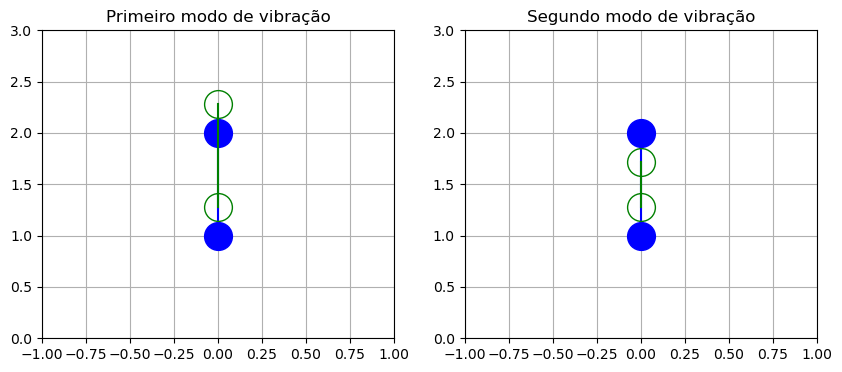

In [5]:
pos = np.array([2, 1])

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot([0, 0], pos, 'bo-', markersize=20)
plt.plot([0, 0], pos+4*Phi[:,0], 'go-', markerfacecolor='none', markersize=20)
plt.axis([-1, 1, 0, 3])
plt.title('Primeiro modo de vibração')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot([0, 0], pos, 'bo-', markersize=20)
plt.plot([0, 0], pos+4*Phi[:,1], 'go-', markerfacecolor='none', markersize=20)
plt.axis([-1, 1, 0, 3])
plt.title('Segundo modo de vibração')  
plt.grid(True)


### Questão 1b (sistema discreto, vibração forçada):

A gravidade $g \approx 9.81{\rm m/s^2}$ é "ligada" subitamente, tal como uma função passo unitário. 
Usando superposição modal, calcule as amplitudes e faça o gráfico do deslocamento $u_2(t)$. (2.5pts)

### _Solução_:

A gravidade implica em um vetor peso atuando nas duas massas simultaneamente. 
Vamos então construir esse vetor e a partir dele construir as forças modais nos dois primeiros modos.
As forças modais serão usadas para construir um objeto ```MRPy``` com duração de 30s (tempo de integração) discretizados em 4096 passos de tempo. 


In [6]:
g  = 9.81

F  = g*np.matmul(M, np.ones((2, 4096)))
Fk = MRPy(np.matmul(Phi.T, F), Td=30.)


A questão será resolvida numericamente, para os dois modos de vibração.
Para usarmos o método ```sdof_Duhamel``` precisamos dividir as forças modais 
pelas massas modais. 

In [7]:
Mk1 = np.dot(Phi[:,0], np.dot(M, Phi[:,0]))
Mk2 = np.dot(Phi[:,1], np.dot(M, Phi[:,1]))

print('Massa modal no primeiro modo: {0:6.2f} kg  '.format(Mk1))
print('Massa modal no segundo modo:  {0:6.2f} kg\n'.format(Mk2))


Massa modal no primeiro modo:   1.00 kg  
Massa modal no segundo modo:    1.00 kg



Observa-se que a função que faz a análise modal já normalizou as formas modais pela matriz de massa, portanto as massas modais são todas unitárias.

Assim, os deslocamentos modais são obtidos abaixo com amortecimento de 1%.

In [8]:
uk = Fk.sdof_Duhamel(fk, 0.01)

O deslocamento $u_2(t)$ resulta portanto:

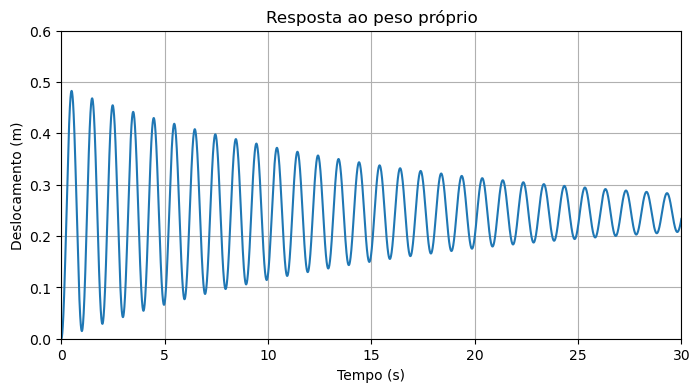

In [9]:
u = np.dot(Phi, uk)
t = uk.t_axis()

plt.figure(figsize=(8,4))
plt.plot(t, u[1,:])

plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento (m)')
plt.title('Resposta ao peso próprio')
plt.axis([0, 30, 0, 0.6])
plt.grid()
plt.show()

Observe que a solução estática, para a qual a solução dinâmica converge, é:

In [10]:
Fe = 100*g*np.array([[1],[1]])   # peso como força estática
ue = np.linalg.solve(K, Fe)      # solução estática para peso próprio

print('Deslocamento estático u1(t): {0:5.2f} m'.format(ue[0,0]))
print('Deslocamento estático u2(t): {0:5.2f} m'.format(ue[1,0]))

Deslocamento estático u1(t):  0.25 m
Deslocamento estático u2(t):  0.25 m


Observa-se que não há participação do segundo modo, já que a distribuição da carga
coincide _exatamente_ com a primeira forma modal (mesmo valor de coordenada para os
dois g.d.l.). Além disso, como é sabido para a resposta a um passo unitário,
o valor de pico do deslocamento é aproximadamento o dobro do seu valor estático.

## Questão 2

A barra vertical bi-engastada tem comprimento $L = 10{\rm m}$, rigidez à flexão $EI = 1000{\rm kNm^2}$, e massa por unidade de comprimento $\mu = 1000{\rm kg/m}$. O amortecimento em todos os modos de vibração é 1%.

<img src="resources/tests/PEC00025A_261_P2_Q2.png" alt="PEC00025A_261_P2_Q2" width="240px"/>

### Questão 2a (sistema contínuo, vibração livre):

Proponha uma função $\varphi(x)$ que aproxime a forma modal do primeiro modo 
de vibração livre. 
Use o quociente de Rayleigh para estimar a frequência natural correspondente. (2.5pts)

### _Solução_:

Vamos usar a linha elástica usando uma função trigonométrica, mas que respeita 
as condições de contorno.

$$ \varphi(x) = \frac{1}{2} \left[ 1 - \cos{\left( \frac{2\pi x }{L} \right)} \right]
              = \frac{1}{2} \left[ 1 - \cos{\left(       2\pi \xi    \right)} \right]$$

Abaixo está a visualização da função escolhida.



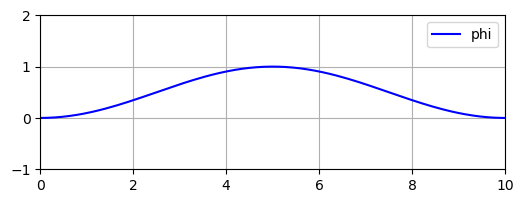

In [11]:
L   =  10
EI  =  1.e6
mu  =  100

x   =  np.linspace(0, L, 128)
phi = (1 - np.cos(2*np.pi*x/L))/2

plt.figure(1, figsize=(6,2), clear=True)
plt.plot(x, phi, 'b')
plt.axis([0, L, -1, 2])
plt.legend(('phi',))
plt.grid(True)


As derivadas dessa função proposta são:

$$ \varphi'(x)  = \frac{2\pi}  {L}   \sin{\left( \frac{2\pi  x }{L} \right)} 
                = \frac{2\pi}  {L}   \sin{\left(       2\pi \xi     \right)}$$
$$ \varphi''(x) = \frac{4\pi^2}{L^2} \cos{\left( \frac{2\pi  x}{L}   \right)} 
                = \frac{4\pi^2}{L^2} \cos{\left(       2\pi \xi     \right)}$$

onde $\xi = x/L$. 
Portanto, a energia potencial elástica é:

$$ V = \frac{1}{2}   \int_0^L{ EI \left[ \varphi''(x)   \right]^2 \; dx  } 
     = \frac{EIL}{2} \int_0^1{    \left[ \varphi''(\xi) \right]^2 \; d\xi} 
     = \frac{EIL}{2} \cdot \left( \frac{4\pi^2}{L^2} \right)^2 \cdot \frac{1}{2}$$

A energia cinética de referência é:

$$ T_{\rm ref} = \frac{1}{2}     \int_0^L{ \mu \left[ \varphi(x)   \right]^2 \; dx  } 
               = \frac{\mu L}{2} \int_0^1{     \left[ \varphi(\xi) \right]^2 \; d\xi}
               = \frac{\mu L}{2} \cdot \left( \frac{1}{2} \right)^2 \cdot \frac{3}{2}$$

Dividindo as duas formas de energia, chega-se à frequência fundamental:

$$ \frac{V}{T_{\rm ref}} = \omega_1^2 
                         = \frac{4 \pi^4 EI}{L^3}  \cdot \frac{16}{3\mu L}
                         \approx \left( \frac{6.7517}{L} \right)^4 \frac{EI}{\mu}$$


Ou seja, como a participação do primeiro modo é mais importante, e como a combinação de modos é quadrática (sinal irrelevante)
chega-se ao mesmo resultado em deslocamento para as duas massas.


## Questão 2b (sistema contínuo, vibração forçada)

Calcule e faça o gráfico do deslocamento no centro do vão para uma força externa aplicada,
$F(t) = F_0 \sin (2\pi f_0 t)$ , com $F_0 = 1{\rm kN}$ e $f_0 = 1{\rm Hz}$. (2.5pts)


### Solução:




Logo a energia cinética de referência é:

$$ 2T_{{\rm ref},A} = \int_0^L {\mu \, \varphi_A^2(\xi) \; dx} = \frac{\mu L}{2}$$

$$ 2T_{{\rm ref},B} = \int_0^L {\mu \, \varphi_B^2(\xi) \; dx} = \frac{2\mu L}{3}$$

e a energia potencial elástica é:

$$ 2V_A = \int_0^L{EI \,\left[ \varphi_A^{\prime \prime}(\xi)\right] ^2 \; dx} = \frac{\pi^4 EI}{2L^3} $$

$$ 2V_B = \int_0^L{EI \,\left[ \varphi_B^{\prime \prime}(\xi)\right] ^2 \; dx} = \frac{64 EI}{L^3} $$

Portanto, pelo quociente de Rayleigh temos:

$$ \omega^2_{{\rm n},A} = \frac{V_A} {T_{{\rm ref},A}} 
                         = \left( \frac{\pi} {L} \right)^4 \frac{EI}{\mu} $$

$$ \omega^2_{{\rm n},B} = \frac{V_B}{T_{{\rm ref},B}} 
                        \approx \left( \frac{ 3.1302}{L} \right)^4 \frac{EI}{\mu} $$

Observa-se que os dois resultados são bem próximos, sendo que o primeiro é exato pois a forma modal
senoidal é a correta.


In [ ]:
f1A = ((np.pi /L)**2) * np.sqrt(EI/mu) / (2*np.pi)
f1B = ((3.1302/L)**2) * np.sqrt(EI/mu) / (2*np.pi)

print('Frequência no primeiro modo (senóide):  {0:6.3f} Hz'.format(f1A)) 
print('Frequência no primeiro modo (parábola): {0:6.3f} Hz\n'.format(f1B)) 


Verifica-se, portanto, que ambas as formas modais fornecem resultados próximos, sendo que a forma modal $\varphi_A(x)$ (exata)
conduz à frequência correta. Estes valores também estão próximos ao resultado obtido na questão (1), com a massa da
viga discretizada em duas massas concentradas.


## Questão 4

A viga do problema anterior é subitamente submetida ao seu peso próprio. Ou seja, o seu peso próprio é aplicado como uma função passo unitário no instante $t = 0$s. Estime o máximo deslocamento vertical que ocorrerá no centro da viga. Utilize nos cálculos a mesma forma modal adotada na questão anterior. (sistema contínuo, carga transiente)


### Solução

A carga distribuída atuante na viga é dada por:

$$ q(t) = \mu g h(t) $$

onde $g \approx 9.81 {\rm m/s^2}$ é a aceleração da gravidade e $h(t)$ é a função passo unitário com o passo dado em $t = 0$s.
A força modal para o modo 1 é portanto:

$$ F_1(t) = \int_0^L {q(t) \varphi_A(x) \; dx} = \mu g h(t) \cdot \int_0^L {\sin (\pi x/L) \; dx} = \frac{2 m g}{\pi} \cdot h(t)$$

Como a forma modal $\varphi_A(x)$ tem escala unitária, precisamos calcular a massa e a rigidez modais:

$$ M_1 = \int_0^L {\mu \varphi_A^2(x) \; dx} = \frac{m}{2} $$

$$ K_1 = M_1 \omega_1^2 = \frac{m \omega_1^2}{2}$$


<img src="images/dynamic_factors.jpg" alt="acceleration spectrum" width="540px"/>

O deslocamento modal para este tipo de ação (carga passo unitário com duração infinita) é calculado através do gráfico como:

$$ u_{1, {\rm din}} = A \cdot u_{1, {\rm est}} = A \cdot \frac{F_1}{K_1} 
                    = A \cdot \frac{2 m g}{\pi} \cdot \frac{2}{ m \omega_1^2}
                    = A \cdot \frac{  4 g}{\pi \omega_1^2} $$

O fator dinâmico para esta forma de carga é $A = 2$. 
Como a forma modal tem amplitude unitária no centro do vão, o valor numérico do deslocamento máximo neste ponto
é igual ao valor do deslocamento modal. Portanto:

$$ u_{\rm max} = \varphi_1(L/2) \cdot u_{1, {\rm din}} = \frac{8 g}{\pi \omega_1^2}$$

onde $\varphi_1(L/2) = 1$.


In [ ]:
umax = 8*9.81/(np.pi*wk[0]**2)

print('Máximo deslocamento no centro do vão: {0:6.4f} mm\n'.format(1000*umax)) 


In [ ]:
print()